In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img=cv2.imread("mountain.jpg")
img.shape

(181, 278, 3)

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

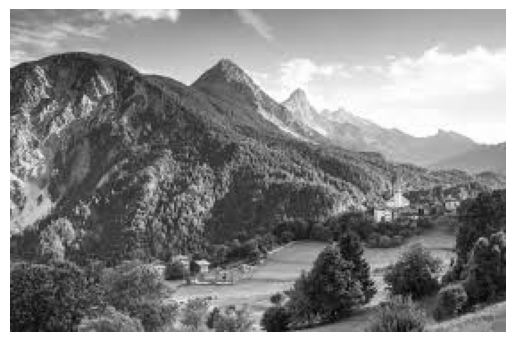

In [3]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray,cmap="gray")
plt.axis('off')

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

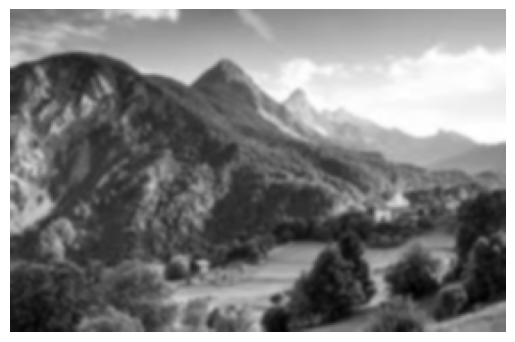

In [4]:
img_gauss = cv2.GaussianBlur(img_gray,(5,5),0)
plt.imshow(img_gauss,cmap="gray")
plt.axis('off')

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

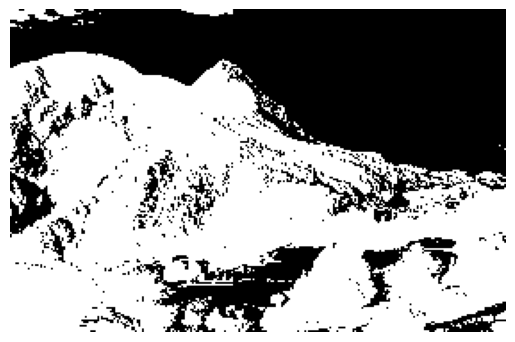

In [5]:
ret, thresh = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
plt.imshow(thresh,cmap="gray")
plt.axis('off')

In [6]:
kernel = np.ones((9, 9), np.uint8)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
bg = cv2.dilate(closing, kernel, iterations=2)

In [7]:
contours, _ = cv2.findContours(
    closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [8]:
result = np.zeros(img_gray.shape, dtype=np.uint8)

In [9]:
for contour in contours:
    if cv2.contourArea(contour)>1000:
        cv2.fillPoly(result,[contour],255)

In [10]:
kernel_open = np.ones((6, 6), np.uint8)
opened_result = cv2.morphologyEx(result, cv2.MORPH_OPEN, kernel_open, iterations=2)

In [11]:
kernel_erode = np.ones((9, 9), np.uint8)
final_result = cv2.erode(opened_result, kernel_erode, iterations=2)

(np.float64(-0.5), np.float64(277.5), np.float64(180.5), np.float64(-0.5))

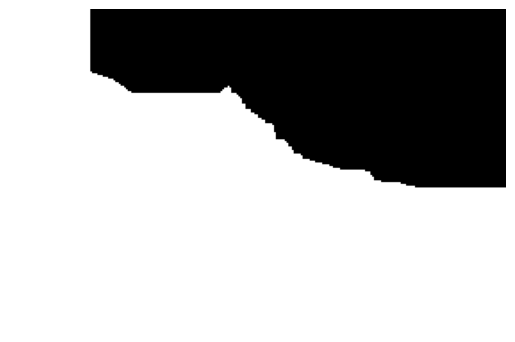

In [12]:
plt.imshow(final_result, cmap="gray")
plt.axis('off')